In [1]:
# downloading important libraries
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
# from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

In [2]:
# Function
def split_scalar(indep_X,dep_Y):
        X_train, X_test, y_train, y_test = train_test_split(indep_X, dep_Y, test_size = 0.25, random_state = 0)
        sc = StandardScaler()  # to treat/convert all input varialbes/features with in range
        X_train = sc.fit_transform(X_train)  # It learns the scale of your training data and converts it into standardized form (mean = 0, std = 1)
        X_test = sc.transform(X_test) # for testing fit_transform as no conversion required for test data and here only testing on raw data   
        return X_train, X_test, y_train, y_test

In [3]:
# Function
def r2_prediction(regressor,X_test,y_test):
     y_pred = regressor.predict(X_test) # for the X_test input predicting the output and storing into y_pred
     from sklearn.metrics import r2_score
     r2=r2_score(y_test,y_pred) # comparison between actual output and predicted output
     return r2

In [4]:
# Function
def Linear(X_train,y_train,X_test):       
        # Fitting K-NN to the Training set
        from sklearn.linear_model import LinearRegression
        regressor = LinearRegression()
        regressor.fit(X_train, y_train) # Model Creation
        r2=r2_prediction(regressor,X_test,y_test) # Prediction
        return  regressor   

In [5]:
# Function
def svm_linear(X_train,y_train,X_test):
                
        from sklearn.svm import SVR
        regressor = SVR(kernel = 'linear')
        regressor.fit(X_train, y_train) # Model Creation
        r2=r2_prediction(regressor,X_test,y_test) # Prediction
        return  regressor 

In [6]:
# Function
def svm_NL(X_train,y_train,X_test):
                
        from sklearn.svm import SVR
        regressor = SVR(kernel = 'rbf')
        regressor.fit(X_train, y_train) # Model Creation
        r2=r2_prediction(regressor,X_test,y_test) # Prediction
        return  regressor  

In [7]:
# Function
def Decision(X_train,y_train,X_test):
        
        # Fitting K-NN to the Training setC
        from sklearn.tree import DecisionTreeRegressor
        regressor = DecisionTreeRegressor(random_state = 0)
        regressor.fit(X_train, y_train) # Model Creation
        r2=r2_prediction(regressor,X_test,y_test) # Prediction
        return  regressor 

In [8]:
# Function
def random(X_train,y_train,X_test):       
        # Fitting K-NN to the Training set
        from sklearn.ensemble import RandomForestRegressor
        regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
        regressor.fit(X_train, y_train) # Model Creation
        r2=r2_prediction(regressor,X_test,y_test) # Prediction
        return  regressor 

In [9]:
# Function: Feature Importance
# It helps you interpret the model:
# Which features influence output the most?
# Is the model behaving logically?
# A feature importance algorithm tells you how much each feature (column) contributes to the prediction.

# For example:

#Predicting house price 
#→ Features: size, location, number of rooms
#→ Feature importance tells you:
#Size = very important
#Location = important
#Number of rooms = less important

def featureImportance(feature_names, model, indep_X, dep_Y, n):

    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.inspection import permutation_importance

    # Only if model supports feature_importances_
    if hasattr(model, "feature_importances_"):
        mdi_importance = pd.Series(
            model.feature_importances_,
            index=feature_names
        ).sort_values(ascending=False)

        print("MDI Importance:")
        print(mdi_importance)
         # Permutation importance (works for all)
        result = permutation_importance(
            model, indep_X, dep_Y, n_repeats=n, random_state=42, n_jobs=1
        )

        perm_importance = pd.Series(
            result.importances_mean,
            index=feature_names
        ).sort_values(ascending=False)
        print("----------------Custom Message-------------")
        print("\nPermutation Importance:")
        print("-------------------------------------------")
        print(perm_importance)
        print("-------------------------------------------")
        # 4. Visualize the results
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        mdi_importance.plot.bar(ax=axes[0])
        axes[0].set_title("MDI Feature Importance")
        axes[0].set_ylabel("Mean Decrease in Impurity")
        perm_importance.plot.bar(ax=axes[1])
        axes[1].set_title("Permutation Feature Importance (Test Set)")
        axes[1].set_ylabel("Decrease in accuracy score")
        plt.tight_layout()
        plt.show()

    else:
        print("----------------Custom Message-------------")
        print("**** MDI not supported for this model ****")
        print("-------------------------------------------")
        perm_importance=0
   
    
    

    return perm_importance


In [10]:
dataset1=pd.read_csv("Movie_Collection.csv",index_col=None)


In [11]:
dataset1

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,3D_available,Time_taken,Twitter_hastags,Genre,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,YES,109.60,223.840,Thriller,23,494,48000,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,NO,146.64,243.456,Drama,42,462,43200,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,NO,147.88,2022.400,Comedy,38,458,69400,1
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,YES,185.36,225.344,Drama,45,472,66800,1
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,NO,176.48,225.792,Drama,55,395,72400,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,21.2526,78.86,0.427,36624.115,142.6,8.680,8.775,8.620,8.970,6.80,492480,NO,186.96,243.584,Action,27,561,44800,0
502,20.9054,78.86,0.427,33996.600,150.2,8.780,8.945,8.770,8.930,7.80,482875,YES,132.24,263.296,Action,20,600,41200,0
503,21.2152,78.86,0.427,38751.680,164.5,8.830,8.970,8.855,9.010,7.80,532239,NO,109.56,243.824,Comedy,31,576,47800,0
504,22.1918,78.86,0.427,37740.670,162.8,8.730,8.845,8.800,8.845,6.80,496077,YES,158.80,303.520,Comedy,47,607,44000,0


In [12]:
df2=dataset1

df2 = pd.get_dummies(df2, drop_first=True)

In [13]:
df2

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,...,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Collection,Start_Tech_Oscar,3D_available_YES,Genre_Comedy,Genre_Drama,Genre_Thriller
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,...,109.60,223.840,23,494,48000,1,1,0,0,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,...,146.64,243.456,42,462,43200,0,0,0,1,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,...,147.88,2022.400,38,458,69400,1,0,1,0,0
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,...,185.36,225.344,45,472,66800,1,1,0,1,0
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,...,176.48,225.792,55,395,72400,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,21.2526,78.86,0.427,36624.115,142.6,8.680,8.775,8.620,8.970,6.80,...,186.96,243.584,27,561,44800,0,0,0,0,0
502,20.9054,78.86,0.427,33996.600,150.2,8.780,8.945,8.770,8.930,7.80,...,132.24,263.296,20,600,41200,0,1,0,0,0
503,21.2152,78.86,0.427,38751.680,164.5,8.830,8.970,8.855,9.010,7.80,...,109.56,243.824,31,576,47800,0,0,1,0,0
504,22.1918,78.86,0.427,37740.670,162.8,8.730,8.845,8.800,8.845,6.80,...,158.80,303.520,47,607,44000,0,1,1,0,0


In [14]:
#Splitting input and output features
df2 = df2.reset_index(drop=True)
indep_X=df2.drop('Collection', 1) # removing the output column 'Collection' from the input set
dep_Y=df2['Collection'] # keeping only the output column 'Collection' in the output set

In [15]:
indep_X

,Marketing expense,Production expense,Multiplex coverage,Budget,Movie_length,Lead_ Actor_Rating,Lead_Actress_rating,Director_rating,Producer_rating,Critic_rating,Trailer_views,Time_taken,Twitter_hastags,Avg_age_actors,Num_multiplex,Start_Tech_Oscar,3D_available_YES,Genre_Comedy,Genre_Drama,Genre_Thriller
0,20.1264,59.62,0.462,36524.125,138.7,7.825,8.095,7.910,7.995,7.94,527367,109.60,223.840,23,494,1,1,0,0,1
1,20.5462,69.14,0.531,35668.655,152.4,7.505,7.650,7.440,7.470,7.44,494055,146.64,243.456,42,462,0,0,0,1,0
2,20.5458,69.14,0.531,39912.675,134.6,7.485,7.570,7.495,7.515,7.44,547051,147.88,2022.400,38,458,1,0,1,0,0
3,20.6474,59.36,0.542,38873.890,119.3,6.895,7.035,6.920,7.020,8.26,516279,185.36,225.344,45,472,1,1,0,1,0
4,21.3810,59.36,0.542,39701.585,127.7,6.920,7.070,6.815,7.070,8.26,531448,176.48,225.792,55,395,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,21.2526,78.86,0.427,36624.115,142.6,8.680,8.775,8.620,8.970,6.80,492480,186.96,243.584,27,561,0,0,0,0,0
502,20.9054,78.86,0.427,33996.600,150.2,8.780,8.945,8.770,8.930,7.80,482875,132.24,263.296,20,600,0,1,0,0,0
503,21.2152,78.86,0.427,38751.680,164.5,8.830,8.970,8.855,9.010,7.80,532239,109.56,243.824,31,576,0,0,1,0,0
504,22.1918,78.86,0.427,37740.670,162.8,8.730,8.845,8.800,8.845,6.80,496077,158.80,303.520,47,607,0,1,1,0,0


In [16]:
dep_Y

0      48000
1      43200
2      69400
3      66800
4      72400
       ...  
501    44800
502    41200
503    47800
504    44000
505    38000
Name: Collection, Length: 506, dtype: int64

In [17]:
indep_X.isna().sum() #Finding for which column how many NaN values are exist

Marketing expense       0
Production expense      0
Multiplex coverage      0
Budget                  0
Movie_length            0
Lead_ Actor_Rating      0
Lead_Actress_rating     0
Director_rating         0
Producer_rating         0
Critic_rating           0
Trailer_views           0
Time_taken             12
Twitter_hastags         0
Avg_age_actors          0
Num_multiplex           0
Start_Tech_Oscar        0
3D_available_YES        0
Genre_Comedy            0
Genre_Drama             0
Genre_Thriller          0
dtype: int64

In [18]:
indep_X['Time_taken'] = indep_X['Time_taken'].fillna(0) # Replacing the NaN value with 0

In [19]:
feature_names = df2.columns.tolist()

In [20]:
print(feature_names)

['Marketing expense', 'Production expense', 'Multiplex coverage', 'Budget', 'Movie_length', 'Lead_ Actor_Rating', 'Lead_Actress_rating', 'Director_rating', 'Producer_rating', 'Critic_rating', 'Trailer_views', 'Time_taken', 'Twitter_hastags', 'Avg_age_actors', 'Num_multiplex', 'Collection', 'Start_Tech_Oscar', '3D_available_YES', 'Genre_Comedy', 'Genre_Drama', 'Genre_Thriller']


Feature Importance on Linear Algorithm
----------------Custom Message-------------
**** MDI not supported for this model ****
-------------------------------------------
Feature Importance on SVM Linear Algorithm
----------------Custom Message-------------
**** MDI not supported for this model ****
-------------------------------------------
Feature Importance on SVM NL Algorithm
----------------Custom Message-------------
**** MDI not supported for this model ****
-------------------------------------------
Feature Importance on Decision Tree Algorithm
MDI Importance:
Budget                 0.597035
Trailer_views          0.180947
Marketing expense      0.087438
Lead_ Actor_Rating     0.044357
Twitter_hastags        0.024360
Movie_length           0.020349
Director_rating        0.011850
Multiplex coverage     0.006195
Production expense     0.005738
Time_taken             0.004784
Lead_Actress_rating    0.003847
Num_multiplex          0.003702
Producer_rating        0.003543
Avg_age_

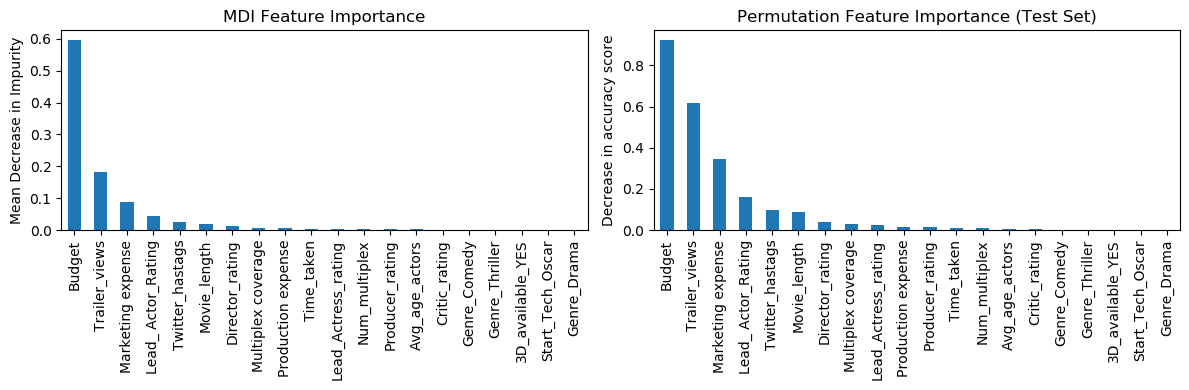

Feature Importance on Random Forest Algorithm
MDI Importance:
Budget                 0.432634
Trailer_views          0.363213
Marketing expense      0.037564
Lead_Actress_rating    0.025413
Director_rating        0.024460
Twitter_hastags        0.021406
Multiplex coverage     0.013813
Movie_length           0.013797
Lead_ Actor_Rating     0.012110
Time_taken             0.010984
Production expense     0.009518
Critic_rating          0.009201
Num_multiplex          0.009094
Producer_rating        0.006894
Avg_age_actors         0.006089
Genre_Drama            0.001203
Start_Tech_Oscar       0.000841
Genre_Comedy           0.000784
Genre_Thriller         0.000686
3D_available_YES       0.000297
dtype: float64
----------------Custom Message-------------

Permutation Importance:
-------------------------------------------
Trailer_views          0.596826
Budget                 0.576354
Marketing expense      0.036131
Twitter_hastags        0.024450
Lead_Actress_rating    0.023691
Director_r

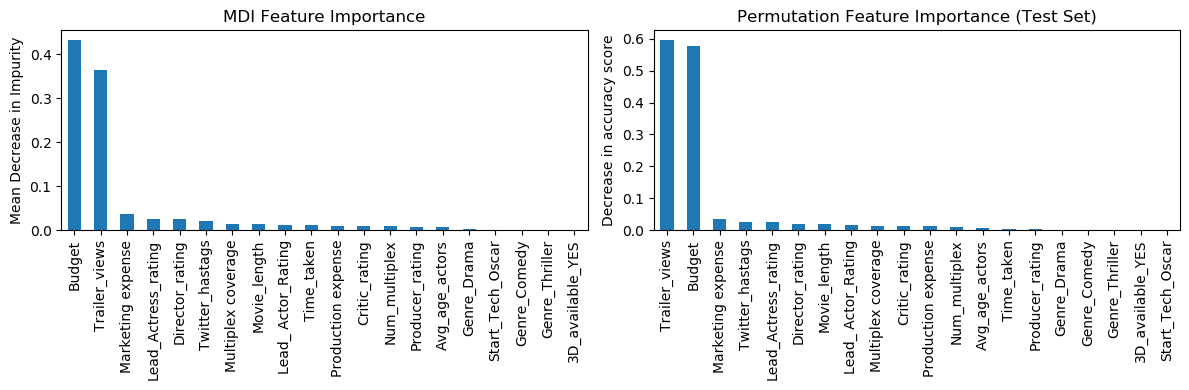

In [21]:
n=3  

X_train, X_test, y_train, y_test = train_test_split(indep_X, dep_Y, test_size = 0.25, random_state = 0)
print("======================================")
print("Feature Importance on Linear Algorithm")
print("======================================")
r2_lin=Linear(X_train,y_train,X_test) 
feature_importance=featureImportance(X_train.columns, r2_lin, X_train,y_train,n)
print("==========================================")
print("Feature Importance on SVM Linear Algorithm")
print("==========================================")
r2_sl=svm_linear(X_train,y_train,X_test)  
feature_importance=featureImportance(X_train.columns, r2_sl, X_train,y_train,n)
    
print("======================================")
print("Feature Importance on SVM NL Algorithm")
print("======================================")
r2_NL=svm_NL(X_train,y_train,X_test)
feature_importance=featureImportance(X_train.columns, r2_NL, X_train,y_train,n)
    
print("=============================================")
print("Feature Importance on Decision Tree Algorithm")
print("=============================================")
r2_d=Decision(X_train,y_train,X_test)
feature_importance=featureImportance(X_train.columns, r2_d, X_train,y_train,n)
    
print("=============================================")
print("Feature Importance on Random Forest Algorithm")
print("=============================================")
r2_r=random(X_train,y_train,X_test)
feature_importance=featureImportance(X_train.columns, r2_r, X_train,y_train,n)
    
    
    
